## Comparing Observations to Models
How do we compare observations to models when we have different grids? In my thesis, I attempt to answer this question. To do so, I use the WOA23 (World Ocean Atlas 2023) dataset - which is a spatial climatology for different inorganic nutrients (Si, PO4, NO3) and also contains physical variables (Temperature, Salinity)- and the Hydrographic Bottle data from CCHDO. 

The main difference is that WOA23 data is already a statistical product, meaning it is only the analyzed mean, whereas the bottle data is singular/discrete observations. This creates a tension, as bottle data is highly spotty. 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


import xarray as xr
from matplotlib.lines import Line2D
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.patches as mpath
from matplotlib.colors import TwoSlopeNorm
import xarray as xr
import xesmf as xe

In [ ]:
## This is the full list of models considered for my thesis but for practice's sake we will use the short version
models = [
    "CESM2", "CESM2-WACCM",
    "GFDL-CM4", "GFDL-ESM4",
    "IPSL-CM6A-LR", 
    "GISS-E2-1-G",
    "MIROC-ES2L",
    "NorCPM1", "NorESM2-LM",
    "MPI-ESM-1-2-HAM", "MPI-ESM1-2-HR", 
    "UKESM1-0-LL",
    "CNRM-ESM2-1",
    "ACCESS-ESM1-5",
    "CanESM5", "CanESM5-CanOE",
    "CMCC-ESM2",

]

# RGB colors, one per model above
_colors_rgb = [
    [255, 255,  38],   # CESM2            - bright yellow
    [255, 159,   0],   # CESM2-WACCM      - orange-amber
    [255,   2,   2],   # GFDL-CM4         - red
    [255, 148, 255],   # GFDL-ESM4        - light magenta
    [255,   6, 255],   # IPSL-CM6A-LR     - magenta
    [127, 245, 206],   # GISS-E2-1-G      - seafoam
    [ 26, 136, 255],   # MIROC-ES2L       - medium blue
    [175, 255, 175],   # NorCPM1          - light green
    [ 17, 137,  14],   # NorESM2-LM       - dark green
    [  8,   8, 126],   # MPI-ESM1-2-HR    - navy
    [ 92,  58,  10],   # MPI-ESM-1-2-HAM  - dark brown
    [112,  48, 160],   # UKESM1-0-LL      - purple
    [184, 184, 255],   # CNRM-ESM2-1      - lavender
    [ 92,  92, 255],   # ACCESS-ESM1-5    - periwinkle
    [  4,   2,   0],   # CanESM5          - near-black
    [ 42,  42,  42],   # CanESM5-CanOE    - dark gray
    [232,  80,   0],   # CMCC-ESM2        - burnt orange

]

In [ ]:
models = [
    "CESM2", "CESM2-WACCM",
     "GFDL-ESM4",
]

# RGB colors, one per model above
_colors_rgb = [
    [255, 255,  38],   # CESM2            - bright yellow
    [255, 159,   0],   # CESM2-WACCM      - orange-amber
    [255, 148, 255],   # GFDL-ESM4        - light magenta
]

colors = np.array([[r/255.0, g/255.0, b/255.0] for r, g, b in _colors_rgb])

Time_months = ("Jul", "Aug", "Sep", "Oct", "Nov", "Dec", 
               "Jan", "Feb", "Mar", "Apr", "May", "Jun")

# Regions and colors
regions = ['siz', 'az', 'pfz', 'saz', 'stz']

region_labels = {r: r.upper() for r in regions}

region_colors = {
    'siz': 'blue',
    'az': 'green',
    'pfz': 'yellow',
    'saz': 'orange',
    'stz': 'red'
}

woa_map = {
    "tos": "t",
    "sos": "s",
    "o2": "o",
    "no3": "n",
    "si": "i",
}

woa_dir = "/glade/u/home/diegovar/summer2025/WOA23/"

In [ ]:
## Loading Zones

zones = {
    "siz": np.load('/glade/u/home/diegovar/teaching/Tutorials/Fronts/siz_grid.npy'),
    "az": np.load('/glade/u/home/diegovar/teaching/Tutorials/Fronts/az_grid.npy'),
    "saz": np.load('/glade/u/home/diegovar/teaching/Tutorials/Fronts/saz_grid.npy'),
    "stz": np.load('/glade/u/home/diegovar/teaching/Tutorials/Fronts/stz_grid.npy'),
    "pfz": np.load('/glade/u/home/diegovar/teaching/Tutorials/Fronts/pfz_grid.npy')}

print("Loaded")

for key in zones:
    zones[key] = zones[key].astype(float)
    zones[key] = np.where(zones[key] == 0, np.nan, zones[key])

siz_zone = zones['siz']
az_zone = zones['az']
saz_zone = zones['saz']
stz_zone = zones['stz']
pfz_zone = zones['pfz']

print(siz_zone.shape)
# masked_ds = ds.where(nmask) 
#boolian values -. True (1) or False (0) 
#SIZ ZONE MASK
mask_siz = np.isnan(np.flipud(siz_zone)) #sends nan values to True, non nans to False
#AZ ZONE MASK
mask_az = np.isnan(np.flipud(az_zone)) #sends nan values to True, non nans to False
#SAZ ZONE MASK
mask_saz = np.isnan(np.flipud(saz_zone)) #sends nan values to True, non nans to False
#STZ ZONE MASK
mask_stz = np.isnan(np.flipud(stz_zone)) #sends nan values to True, non nans to False
#PFZ ZONE MASK
mask_pfz = np.isnan(np.flipud(pfz_zone))  #sends nan values to True, non nans to False


zone_masks = {
    "siz": mask_siz,
    "az": mask_az,
    "pfz": mask_pfz,
    "saz": mask_saz,
    "stz": mask_stz,
    
}

print(mask_pfz)


Loaded
(180, 360)
[[ True  True  True ...  True  True  True]
 [ True  True  True ...  True  True  True]
 [ True  True  True ...  True  True  True]
 ...
 [ True  True  True ...  True  True  True]
 [ True  True  True ...  True  True  True]
 [ True  True  True ...  True  True  True]]


## Time Series Analysis
This first part only considers time series across the zones, meaning that we cannot produce maps from here.

The first analysis only takes into account the WOA23 data, while the second also uses the bottle data.

CPU times: user 930 ms, sys: 299 ms, total: 1.23 s
Wall time: 1.74 s


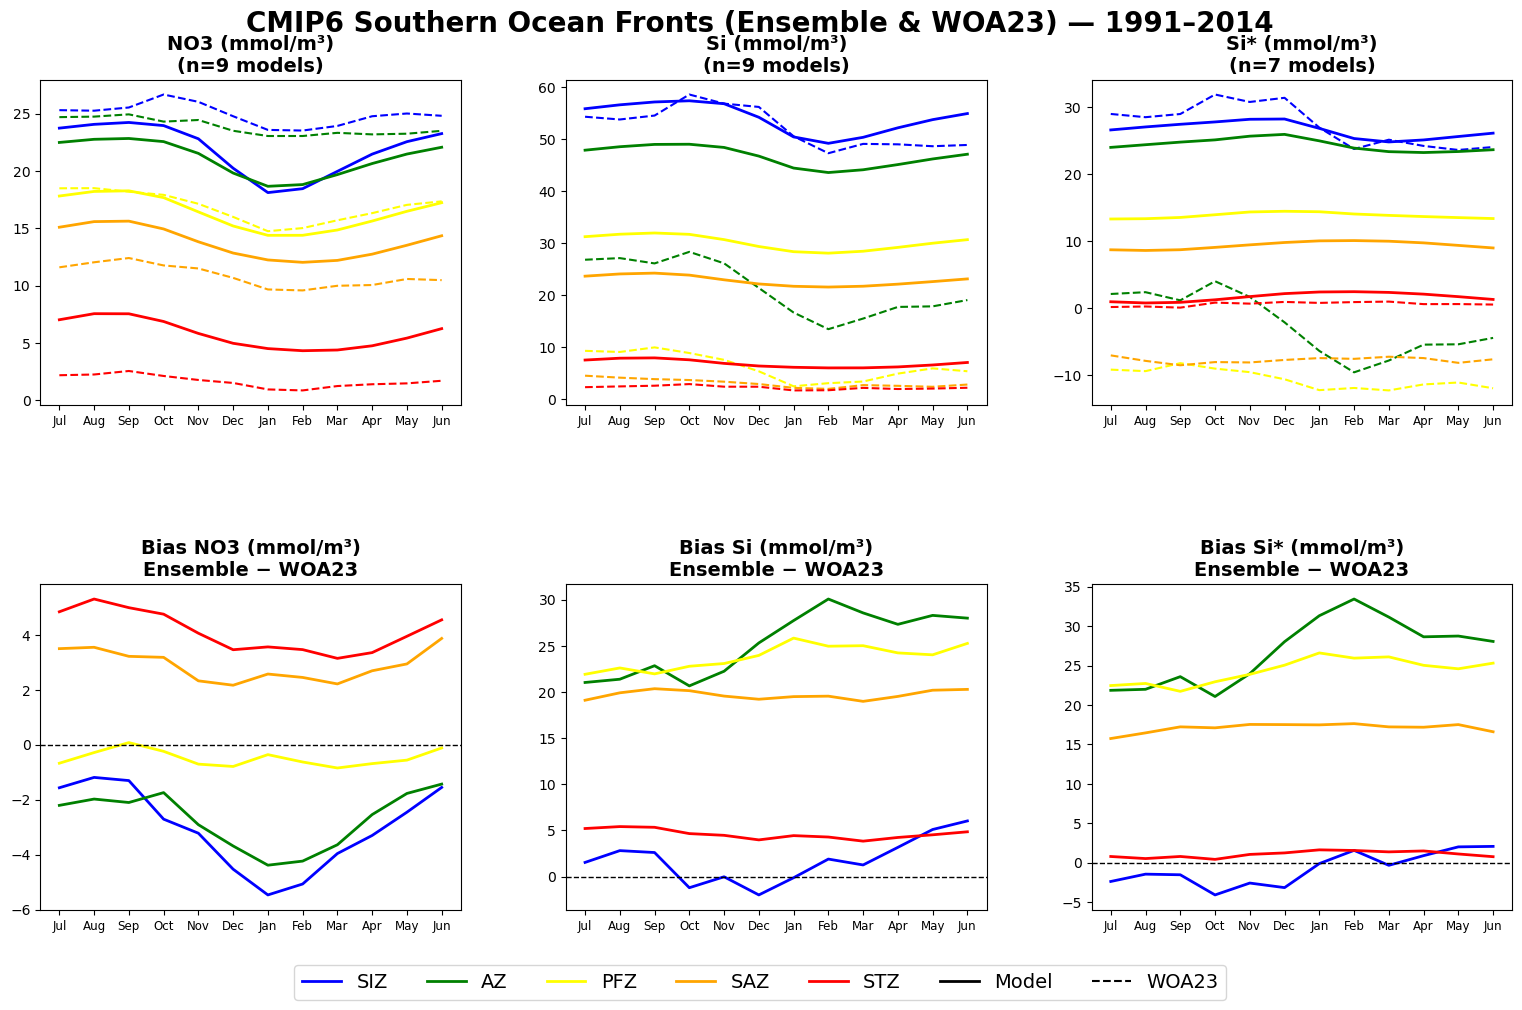

In [ ]:
%%time
start_year = "1991"
end_year = "2014"

var_names  = ["no3", "si", "sistar"]
plot_titles = [
    "NO3 (mmol/m³)",
    "Si (mmol/m³)",
    "Si* (mmol/m³)",
]

woa_map = {"tos": "t", "sos": "s", "o2": "o", "no3": "n", "si": "i"}
woa_dir = "/glade/u/home/diegovar/summer2025/WOA23/"

# =============================================================================
# HELPERS
# =============================================================================
def load_woa(var, region):
    if var == "sistar":
        si_file  = f"{woa_dir}/woa23_fullclim_i_all_an_{region}_mean.nc"
        no3_file = f"{woa_dir}/woa23_fullclim_n_all_an_{region}_mean.nc"
        if os.path.exists(si_file) and os.path.exists(no3_file):
            si  = xr.open_dataset(si_file,  decode_times=False)['i_an'].isel(depth=0).values
            no3 = xr.open_dataset(no3_file, decode_times=False)['n_an'].isel(depth=0).values
            return np.roll(si - no3, -6)
        return None
        
    elif var in woa_map:
        wvar     = woa_map[var]
        period   = "all" if var in ["si", "no3", "po4"] else "A5B4"
        woa_file = f"{woa_dir}/woa23_fullclim_{wvar}_{period}_an_{region}_mean.nc"
        if os.path.exists(woa_file):
            da_vals = xr.open_dataset(woa_file, decode_times=False)[f"{wvar}_an"].isel(depth=0).values
            if var == "po4":
                da_vals = da_vals * 16
            return np.roll(da_vals, -6)
    return None


def load_models(var, region):
    region_data = []
    for model in models:
        ofn = (f"/glade/work/diegovar/climatologiesthesis/"
               f"{model}_{var}_{region}_{start_year}{end_year}.txt")
        if os.path.exists(ofn):
            with open(ofn, "r") as rf:
                values = [float(line.strip()) for line in rf]
            if len(values) == 12:
                region_data.append(np.roll(np.array(values), -6))
    if region_data:
        return np.mean(np.array(region_data), axis=0), len(region_data)
    return None, 0


# =============================================================================
# PLOT — 2 rows × 3 cols
#   Row 1: model ensemble mean (solid) + WOA obs (dashed)
#   Row 2: ensemble mean − WOA bias, with zero reference line
# =============================================================================
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
x = np.arange(1, 13)

for col, var in enumerate(var_names):

    ax_top  = axes[0, col]
    ax_bias = axes[1, col]
    n_models_used = 0

    for region in regions:
        c          = region_colors[region]
        woa_vals   = load_woa(var, region)
        model_mean, n = load_models(var, region)
        n_models_used = max(n_models_used, n)

        # ── Row 1: model (solid) + WOA (dashed) ──────────────────────────
        if model_mean is not None:
            ax_top.plot(x, model_mean, color=c, linestyle='-',
                        linewidth=2, label=region_labels[region])
        if woa_vals is not None:
            ax_top.plot(x, woa_vals, color=c, linestyle='--', linewidth=1.5)

        # ── Row 2: bias = model − WOA ─────────────────────────────────────
        if model_mean is not None and woa_vals is not None:
            bias = model_mean - woa_vals
            ax_bias.plot(x, bias, color=c, linestyle='-',
                         linewidth=2, label=region_labels[region])

    # ── Axis formatting ───────────────────────────────────────────────────
    for ax in (ax_top, ax_bias):
        ax.set_xticks(x)
        ax.set_xticklabels(Time_months, fontsize=8.5)
        ax.set_facecolor("white")

    ax_top.set_title(f"{plot_titles[col]}\n(n={n_models_used} models)",
                     fontsize=14, fontweight='bold')
    ax_bias.set_title(f"Bias {plot_titles[col]}\nEnsemble − WOA23",
                      fontsize=14, fontweight='bold')
    ax_bias.axhline(0, color='k', linewidth=1, linestyle='--')


# =============================================================================
# LEGEND
# =============================================================================
region_legend_elements = [
    Line2D([], [], color=region_colors[r], linestyle='-',
           linewidth=2, label=region_labels[r])
    for r in regions
]
style_legend = [
    Line2D([], [], color='black', linestyle='-',  linewidth=2, label='Model'),
    Line2D([], [], color='black', linestyle='--', linewidth=1.5, label='WOA23'),
]

plt.subplots_adjust(left=0.05, bottom=0.08, right=0.97, top=0.91,
                    hspace=0.55, wspace=0.25)
fig.legend(handles=region_legend_elements + style_legend,
           loc="lower center", fontsize=14,
           bbox_to_anchor=(0.5, -0.02),
           ncol=len(regions) + 2)

plt.suptitle(
    f"CMIP6 Southern Ocean Fronts (Ensemble & WOA23) — {start_year}–{end_year}",
    fontsize=20, fontweight='bold'
)
fig.patch.set_facecolor("white")

#plt.savefig("ActualFig/SouthernOceanModels.png", dpi=600,   bbox_inches="tight", transparent=True)

The second output is the same analysis but calculated with the bottle data. This is not the best way of doing this, as it has tremendous spatial gaps, creating the assumption that all the zone behaves the same.

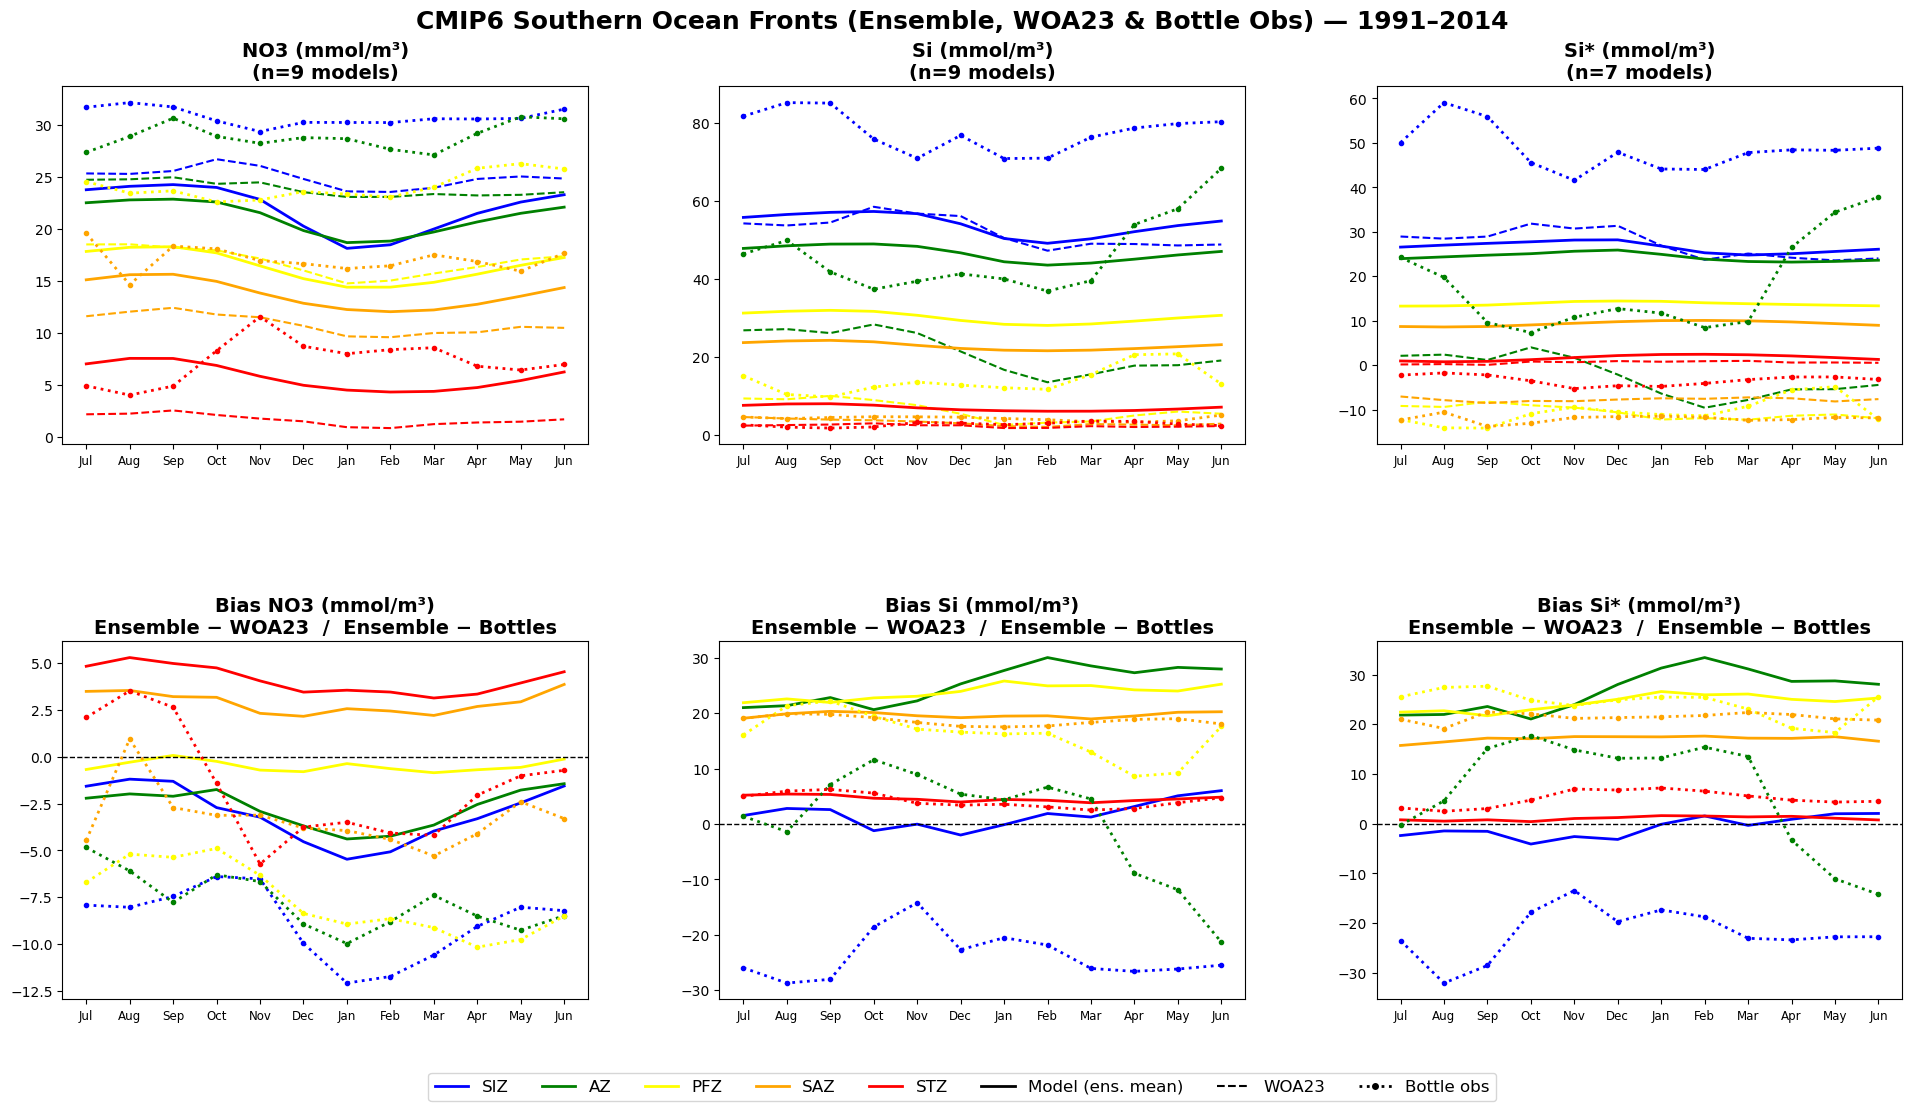

In [ ]:
# ============================================================
# LOAD BOTTLE DATA
# ============================================================
import pandas as pd
from scipy import stats

df_bottles = pd.read_parquet("preprocessed_bottles.parquet")

bottle_var_map = {
    "no3":    "nitrate",
    "si":     "silicate",
    "sistar": "sistar",
}

if "sistar" not in df_bottles.columns:
    df_bottles["sistar"] = df_bottles["silicate"] - df_bottles["nitrate"]

def austral_month_index(cal_month):
    return (cal_month - 7) % 12 + 1

df_bottles["austral_month"] = df_bottles["month"].apply(austral_month_index)

# ============================================================
# HELPER: 3-month rolling mean (no CI)
# ============================================================
def three_month_mean_austral(df_zone, colname):
    result = {}
    for center in range(1, 13):
        months_in = [(center - 2) % 12 + 1,
                     (center - 1) % 12 + 1,
                     center]
        sub = df_zone[df_zone["austral_month"].isin(months_in)][colname].dropna()
        result[center] = sub.mean() if len(sub) > 0 else np.nan
    return result

# ============================================================
# PLOT — 2 rows × 3 cols
#   Row 1: ensemble mean (solid) + WOA23 (dashed) + bottles (dotted)
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(20, 11))
x = np.arange(1, 13)

for col, var in enumerate(var_names):

    ax_top  = axes[0, col]
    ax_bias = axes[1, col]
    n_models_used = 0

    bottle_col = bottle_var_map.get(var)

    for region in regions:
        c = region_colors[region]
        model_mean, n = load_models(var, region)
        n_models_used = max(n_models_used, n)

        # ── Row 1: model (solid) + WOA (dashed) ──────────────────────────
        if model_mean is not None:
            ax_top.plot(x, model_mean, color=c, linestyle="-",
                        linewidth=2, label=region_labels[region])

        # ── Row 1: bottle data (dotted, no shading) ───────────────────────
        if bottle_col is not None and bottle_col in df_bottles.columns:
            sub_zone = df_bottles[df_bottles["zone"] == region]
            if len(sub_zone) > 0:
                cyc = three_month_mean_austral(sub_zone, bottle_col)
                b_means = np.array([cyc[m] for m in range(1, 13)])
                ax_top.plot(x, b_means, color=c, linestyle=":",
                            linewidth=2, marker="o", markersize=3, zorder=5)

        # ── Row 2: model−bottle bias (dotted) ──────────────────────────────
        if bottle_col is not None and bottle_col in df_bottles.columns and woa_vals is not None:
            sub_zone = df_bottles[df_bottles["zone"] == region]
            if len(sub_zone) > 0:
                cyc = three_month_mean_austral(sub_zone, bottle_col)
                b_means = np.array([cyc[m] for m in range(1, 13)])
                bottle_bias = model_mean - b_means 
                ax_bias.plot(x, bottle_bias, color=c, linestyle=":",
                             linewidth=2, marker="o", markersize=3, zorder=5)

    # ── Axis formatting ───────────────────────────────────────────────────
    for ax in (ax_top, ax_bias):
        ax.set_xticks(x)
        ax.set_xticklabels(Time_months, fontsize=8.5)
        ax.set_facecolor("white")

    ax_top.set_title(f"{plot_titles[col]}\n(n={n_models_used} models)",
                     fontsize=14, fontweight="bold")
    ax_bias.set_title(f"Bias {plot_titles[col]}\n Ensemble − Bottles",
                      fontsize=14, fontweight="bold")
    ax_bias.axhline(0, color="k", linewidth=1, linestyle="--")

# ============================================================
# LEGEND
# ============================================================
region_legend_elements = [
    Line2D([], [], color=region_colors[r], linestyle="-",
           linewidth=2, label=region_labels[r])
    for r in regions
]
style_legend = [
    Line2D([], [], color="black", linestyle="-",  linewidth=2,   label="Model (ens. mean)"),
    Line2D([], [], color="black", linestyle=":",  linewidth=2,  marker="o", markersize=6,label="Bottle obs"),
]

plt.subplots_adjust(left=0.05, bottom=0.08, right=0.97, top=0.91,
                    hspace=0.55, wspace=0.25)
fig.legend(handles=region_legend_elements + style_legend,
           loc="lower center", fontsize=12,
           bbox_to_anchor=(0.5, -0.02),
           ncol=len(regions) + 3)

plt.suptitle(
    f"CMIP6 Southern Ocean Fronts (Ensemble,  Bottle Obs) — {start_year}–{end_year}",
    fontsize=18, fontweight="bold"
)
fig.patch.set_facecolor("white")

plt.savefig("ActualFig/SouthernOceanModels_withBottles.png",
            dpi=600, bbox_inches="tight", transparent=True)
plt.show()

## Spatial Analysis
This part of the code is more complex, as it first creates a multi model mean (called ensemble or ens in the code) and uses that to compare spatially.

In [ ]:

var = "sistar"
start_year = "1991"
end_year = "2014"
depthlevel = 0

# Paths
basepath = "/glade/work/diegovar/climatologies_spatial1/"

# Collect available datasets
clims = []
for model in models:
    if depthlevel == 0:
        nc_path = f"{basepath}{model}_{var}_{start_year}{end_year}_spatial.nc"
    else:
        nc_path = f"{basepath}{model}_{var}_{depthlevel}m_{start_year}{end_year}_spatial.nc"

    if os.path.exists(nc_path):
        ds = xr.open_dataset(nc_path)
        clims.append(ds)
    else:
        print(f"Missing: {nc_path}")

# Combine into one dataset
if clims:
    ens = xr.concat(clims, dim="model", coords="minimal", compat="override")    
    ens["model"] = [m for m, ds in zip(models, clims)]

    # Compute multimodel mean
    mm_mean = ens.mean(dim="model", skipna=True)

    # Save multimodel mean
    if depthlevel == 0:
        mm_path = f"{basepath}MultimodelMean_{var}_{start_year}{end_year}_map.nc"
    else:
        mm_path = f"{basepath}MultimodelMean_{var}_{depthlevel}m_{start_year}{end_year}_map.nc"

    mm_mean.to_netcdf(mm_path)
    print(f"Saved multimodel mean to {mm_path}")

else:
    print("No valid model files found.")

Missing: /glade/work/diegovar/climatologies_spatial1/GFDL-CM4_sistar_19912014_spatial.nc
Missing: /glade/work/diegovar/climatologies_spatial1/GISS-E2-1-G_sistar_19912014_spatial.nc
Missing: /glade/work/diegovar/climatologies_spatial1/MIROC-ES2L_sistar_19912014_spatial.nc
Missing: /glade/work/diegovar/climatologies_spatial1/NorCPM1_sistar_19912014_spatial.nc
Missing: /glade/work/diegovar/climatologies_spatial1/MPI-ESM-1-2-HAM_sistar_19912014_spatial.nc
Missing: /glade/work/diegovar/climatologies_spatial1/UKESM1-0-LL_sistar_19912014_spatial.nc
Missing: /glade/work/diegovar/climatologies_spatial1/ACCESS-ESM1-5_sistar_19912014_spatial.nc
Missing: /glade/work/diegovar/climatologies_spatial1/CanESM5_sistar_19912014_spatial.nc
Missing: /glade/work/diegovar/climatologies_spatial1/CanESM5-CanOE_sistar_19912014_spatial.nc
Missing: /glade/work/diegovar/climatologies_spatial1/CMCC-ESM2_sistar_19912014_spatial.nc
Saved multimodel mean to /glade/work/diegovar/climatologies_spatial1/MultimodelMean_si

In [8]:
ens

<xarray.Dataset> Size: 7MB
Dimensions:  (model: 7, month: 12, lat: 60, lon: 360)
Coordinates:
  * model    (model) <U12 336B 'CESM2' 'CESM2-WACCM' ... 'MIROC-ES2L'
  * month    (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
  * lat      (lat) float64 480B -90.0 -89.0 -88.0 -87.0 ... -33.0 -32.0 -31.0
  * lon      (lon) float64 3kB 1.0 2.0 3.0 4.0 5.0 ... 357.0 358.0 359.0 360.0
    lev      float64 8B ...
    olevel   float32 4B ...
Data variables:
    sistar   (model, month, lat, lon) float32 7MB nan nan nan ... -1.088 -0.7897
Attributes:
    model:       CESM2
    variable:    si*
    start_year:  1991
    end_year:    2014
    region:      lat -90 to -30, lon 1 to 361

As you can see here, we have an extra dimension now for the models.

In [9]:
# --- Load Multimodel Mean ---
mm_path = "/glade/work/diegovar/climatologies_spatial1/MultimodelMean_sistar_19912014_map.nc"
mm = xr.open_dataset(mm_path)['sistar'].mean("month")  # yearly mean
mm_lon, mm_lat = mm.lon, mm.lat

# --- Load WOA ---
si_path = "/glade/u/home/diegovar/summer2025/WOA23/woa23_fullclim_i_all_an.nc"
no3_path = "/glade/u/home/diegovar/summer2025/WOA23/woa23_fullclim_n_all_an.nc"

si_ds = xr.open_dataset(si_path, decode_times=False)
no3_ds = xr.open_dataset(no3_path, decode_times=False)

# --- Surface Si and NO3 ---
si_surf = si_ds["i_an"].sel(depth=0)
no3_surf = no3_ds["n_an"].sel(depth=0)
woa_sistar = si_surf - no3_surf
woa_sistar = woa_sistar.mean("time").drop("depth")

# --- Regrid WOA to MM grid ---
woa_grid = xr.Dataset({"lat": mm_lat, "lon": mm_lon})
woa_regridder = xe.Regridder(woa_sistar, woa_grid, "bilinear", periodic=True, ignore_degenerate=True)
woa_sistar_on_mm = woa_regridder(woa_sistar)

# --- Compute difference ---
diff = mm - woa_sistar_on_mm

# --- Determine vmin/vmax from both datasets for consistent colormap ---
vmin = min(mm.min().item(), woa_sistar_on_mm.min().item())
vmax = max(mm.max().item(), woa_sistar_on_mm.max().item())
norm = TwoSlopeNorm(vcenter=0, vmin=vmin, vmax=vmax)

Lon, Lat = mm.lon, mm.lat

/glade/derecho/scratch/diegovar/tmp/ipykernel_90536/1524561687.py:17: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  woa_sistar = woa_sistar.mean("time").drop("depth")


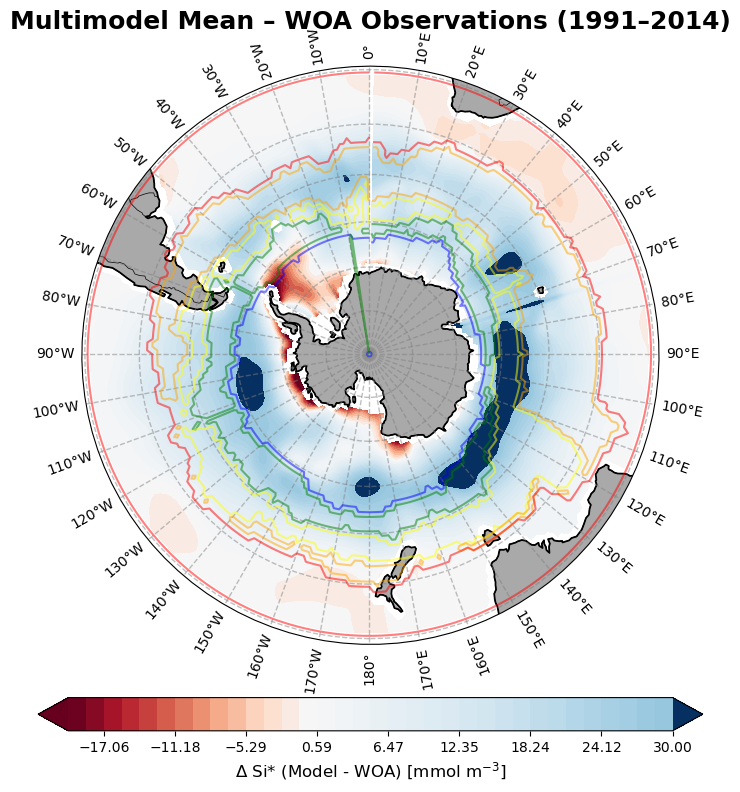

In [10]:
Lon, Lat = mm.lon, mm.lat

fig = plt.figure(figsize=(12, 8))
ax = plt.axes(projection=ccrs.SouthPolarStereo())
ax.set_extent([-180, 180, -90, -35], ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, color="darkgrey")
ax.add_feature(cfeature.OCEAN, color="white")
ax.add_feature(cfeature.COASTLINE, linewidth=1.25)

# Meridian + parallel gridlines
ax.gridlines(
    crs=ccrs.PlateCarree(), draw_labels=True, linewidth=1,
    xlocs=range(-180, 171, 10), ylocs=[],
    color="gray", alpha=0.5, linestyle="--", zorder=10
)
ax.gridlines(
    crs=ccrs.PlateCarree(), draw_labels=False, linewidth=1,
    xlocs=[], ylocs=None,
    color="gray", alpha=0.5, linestyle="--", zorder=10
)

# Circular boundary
theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)
ax.set_boundary(circle, transform=ax.transAxes)


im = ax.contourf(
    Lon, Lat, diff,
    levels=np.linspace(-20, 30, 35),
    cmap="RdBu",
    norm=norm,
    extend="both",
    transform=ccrs.PlateCarree()
)
Lat = np.arange(-90,90)
# --- Overlay biome/front boundaries ---
for reg, mask in zone_masks.items():
    ax.contour(
        Lon, Lat, mask,
        levels=[0.5],
        colors=region_colors[reg],
        linewidths=1.5,
        alpha=0.5,
        transform=ccrs.PlateCarree()
    )

# --- Map features ---
ax.coastlines(linewidth=0.8)
ax.add_feature(cfeature.BORDERS, edgecolor="black", linewidth=0.5)
ax.set_extent([-180, 180, -90, -29], crs=ccrs.PlateCarree())

# --- Colorbar ---
cbar = plt.colorbar(im, ax=ax, orientation="horizontal", fraction=0.05, pad=0.08)
cbar.set_label("Δ Si* (Model - WOA) [mmol m$^{-3}$]", size=12)

plt.title("Multimodel Mean – WOA Observations (1991–2014)", size=18, weight="bold", y=1.05)
plt.tight_layout()
plt.savefig("ActualFig/si_star_diff_models_vs_WOA.png", transparent=True, dpi=300)
plt.show()

Occupied 5°×5° DJF cells (≥2 distinct years): 256
Cells with valid model + bottle DJF data: 213


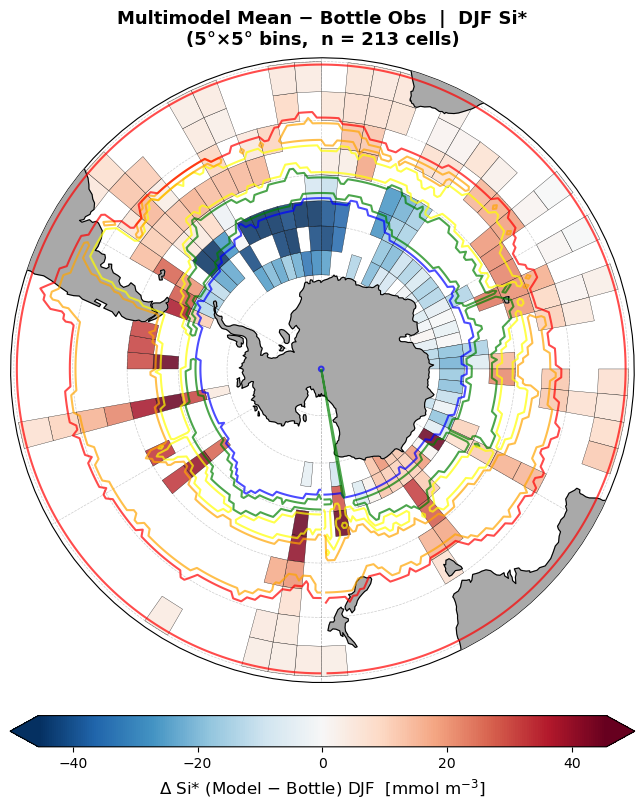

Saved → ActualFig/sistar_DJF_model_minus_bottle.png


In [11]:
# ============================================================
# LOAD ENSEMBLE MEAN & EXTRACT DJF (months 12, 1, 2)
# ============================================================
import os
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.cm as cm
from matplotlib.colors import TwoSlopeNorm
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.path as mpath

var        = "sistar"
start_year = "1991"
end_year   = "2014"
depthlevel = 0
basepath   = "/glade/work/diegovar/climatologies_spatial1/"

# ── Load or reuse ensemble mean ───────────────────────────────────────────────
mm_path = (f"{basepath}MultimodelMean_{var}_{start_year}{end_year}_map.nc"
           if depthlevel == 0 else
           f"{basepath}MultimodelMean_{var}_{depthlevel}m_{start_year}{end_year}_map.nc")

if not os.path.exists(mm_path):
    clims = []
    for model in models:
        nc_path = (f"{basepath}{model}_{var}_{start_year}{end_year}_spatial.nc"
                   if depthlevel == 0 else
                   f"{basepath}{model}_{var}_{depthlevel}m_{start_year}{end_year}_spatial.nc")
        if os.path.exists(nc_path):
            clims.append(xr.open_dataset(nc_path))
        else:
            print(f"Missing: {nc_path}")
    ens            = xr.concat(clims, dim="model", coords="minimal", compat="override")
    ens["model"]   = [m for m, _ in zip(models, clims)]
    mm_mean        = ens.mean(dim="model", skipna=True)
    mm_mean.to_netcdf(mm_path)
    print(f"Saved multimodel mean → {mm_path}")

mm = xr.open_dataset(mm_path)[var]   # dims: (month, lat, lon)

# DJF = months 12, 1, 2  (model files use 1-based month index)
mm_djf = mm.sel(month=[12, 1, 2]).mean(dim="month")   # (lat, lon)


mm_lon = mm_djf.lon.values   # 1–361 convention
mm_lat = mm_djf.lat.values   # -90 to 90

# ============================================================
# LOAD BOTTLE DATA & COMPUTE 5°×5° DJF MEAN
# ============================================================
df_bottles = pd.read_parquet("preprocessed_bottles.parquet")

if "sistar" not in df_bottles.columns:
    df_bottles["sistar"] = df_bottles["silicate"] - df_bottles["nitrate"]

BIN = 5

def bin_center(val, binsize=BIN):
    return np.floor(val / binsize) * binsize + binsize / 2

df_bottles["lat_bin"] = df_bottles["lat"].apply(bin_center)
df_bottles["lon_bin"] = df_bottles["lon"].apply(bin_center)

# Keep only DJF samples
# Count distinct years per cell, then filter
df_djf = df_bottles[df_bottles["season"] == "DJF"].copy()

bottle_djf = (
    df_djf
    .groupby(["lat_bin", "lon_bin"])
    .agg(
        mean  = ("sistar", "mean"),
        n     = ("sistar", "count"),
        years = ("year",   lambda x: x.nunique()),
    )
    .reset_index()
)

# Keep only cells sampled across at least 3 distinct years
bottle_djf = bottle_djf[bottle_djf["years"] >= 2].copy()

print(f"Occupied 5°×5° DJF cells (≥2 distinct years): {len(bottle_djf)}")

# ============================================================
# SAMPLE MODEL AT EACH BOTTLE BIN CENTER → COMPUTE DIFF
# ============================================================
# Convert bottle lon_bin (-180/180) to model lon convention (1–361)
bottle_djf["lon_bin_conv"] = ((bottle_djf["lon_bin"] + 180) % 360) + 1

diffs = []
for _, row in bottle_djf.iterrows():
    lat_c   = row["lat_bin"]
    lon_c   = row["lon_bin_conv"]
    bot_val = row["mean"]
    n_obs   = row["n"]

    lat_idx = int(np.argmin(np.abs(mm_lat - lat_c)))
    lon_idx = int(np.argmin(np.abs(mm_lon - lon_c)))
    mod_val = float(mm_djf.values[lat_idx, lon_idx])

    if np.isfinite(mod_val) and np.isfinite(bot_val):
        diffs.append({
            "lat":    lat_c,
            "lon":    row["lon_bin"],   # -180/180 for PlateCarree
            "diff":   mod_val - bot_val,
            "n":      n_obs,
        })

df_diff = pd.DataFrame(diffs)
print(f"Cells with valid model + bottle DJF data: {len(df_diff)}")

# ============================================================
# PLOT
# ============================================================
vabs     = np.nanpercentile(np.abs(df_diff["diff"]), 95)
norm_map = TwoSlopeNorm(vcenter=0, vmin=-vabs, vmax=vabs)
cmap_map = cm.RdBu_r

proj = ccrs.SouthPolarStereo(central_longitude=0)
fig, ax = plt.subplots(
    1, 1,
    figsize=(8, 8),
    subplot_kw={"projection": proj},
    constrained_layout=True,
)

# ── Polar axis ────────────────────────────────────────────────────────────────
ax.set_extent([-180, 180, -90, -29], ccrs.PlateCarree())
ax.add_feature(cfeature.LAND,      color="darkgrey", zorder=4)
ax.add_feature(cfeature.COASTLINE, linewidth=0.8,    zorder=5)
ax.gridlines(
    crs=ccrs.PlateCarree(), linewidth=0.5,
    color="gray", alpha=0.4, linestyle="--", zorder=2,
)
theta  = np.linspace(0, 2 * np.pi, 100)
verts  = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * 0.5 + 0.5)
ax.set_boundary(circle, transform=ax.transAxes)

# ── One filled square per 5°×5° cell ─────────────────────────────────────────
for _, row in df_diff.iterrows():
    lat0 = row["lat"] - BIN / 2
    lat1 = row["lat"] + BIN / 2
    lon0 = row["lon"] - BIN / 2
    lon1 = row["lon"] + BIN / 2
    clr  = cmap_map(norm_map(row["diff"]))
    ax.fill(
        [lon0, lon1, lon1, lon0, lon0],
        [lat0, lat0, lat1, lat1, lat0],
        color=clr, alpha=0.85,
        transform=ccrs.PlateCarree(), zorder=3,
        edgecolor="k", linewidth=0.25,
    )

# ── Frontal zone boundaries ───────────────────────────────────────────────────
Lat_mask = np.arange(-90, 90)
for reg, mask in zone_masks.items():
    ax.contour(
        np.arange(-180, 180),
        Lat_mask,
        mask.astype(float),
        levels=[0.5],
        colors=region_colors[reg],
        linewidths=1.5,
        alpha=0.7,
        transform=ccrs.PlateCarree(),
        zorder=6,
    )

# ── Colorbar ──────────────────────────────────────────────────────────────────
sm = cm.ScalarMappable(cmap=cmap_map, norm=norm_map)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, orientation="horizontal",
                    fraction=0.05, pad=0.05, extend="both")
cbar.set_label("Δ Si* (Model − Bottle) DJF  [mmol m$^{-3}$]", size=12)

ax.set_title(
    f"Multimodel Mean − Bottle Obs  |  DJF Si*\n"
    f"({BIN}°×{BIN}° bins,  n = {len(df_diff)} cells)",
    fontsize=13, fontweight="bold", pad=10,
)

plt.savefig("ActualFig/sistar_DJF_model_minus_bottle.png",
            dpi=400, bbox_inches="tight", transparent=True)
plt.show()
print("Saved → ActualFig/sistar_DJF_model_minus_bottle.png")

Here, the thought process was to create a grid (5° by 5°) in which the observations are averaged, which are then compared against with the same grid of the model.

/glade/derecho/scratch/diegovar/tmp/ipykernel_90536/1329427504.py:79: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  clr  = cm.get_cmap(cmap_shared)(norm_shared(row["diff"]))
/glade/derecho/scratch/diegovar/tmp/ipykernel_90536/1329427504.py:79: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  clr  = cm.get_cmap(cmap_shared)(norm_shared(row["diff"]))
/glade/derecho/scratch/diegovar/tmp/ipykernel_90536/1329427504.py:79: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cl

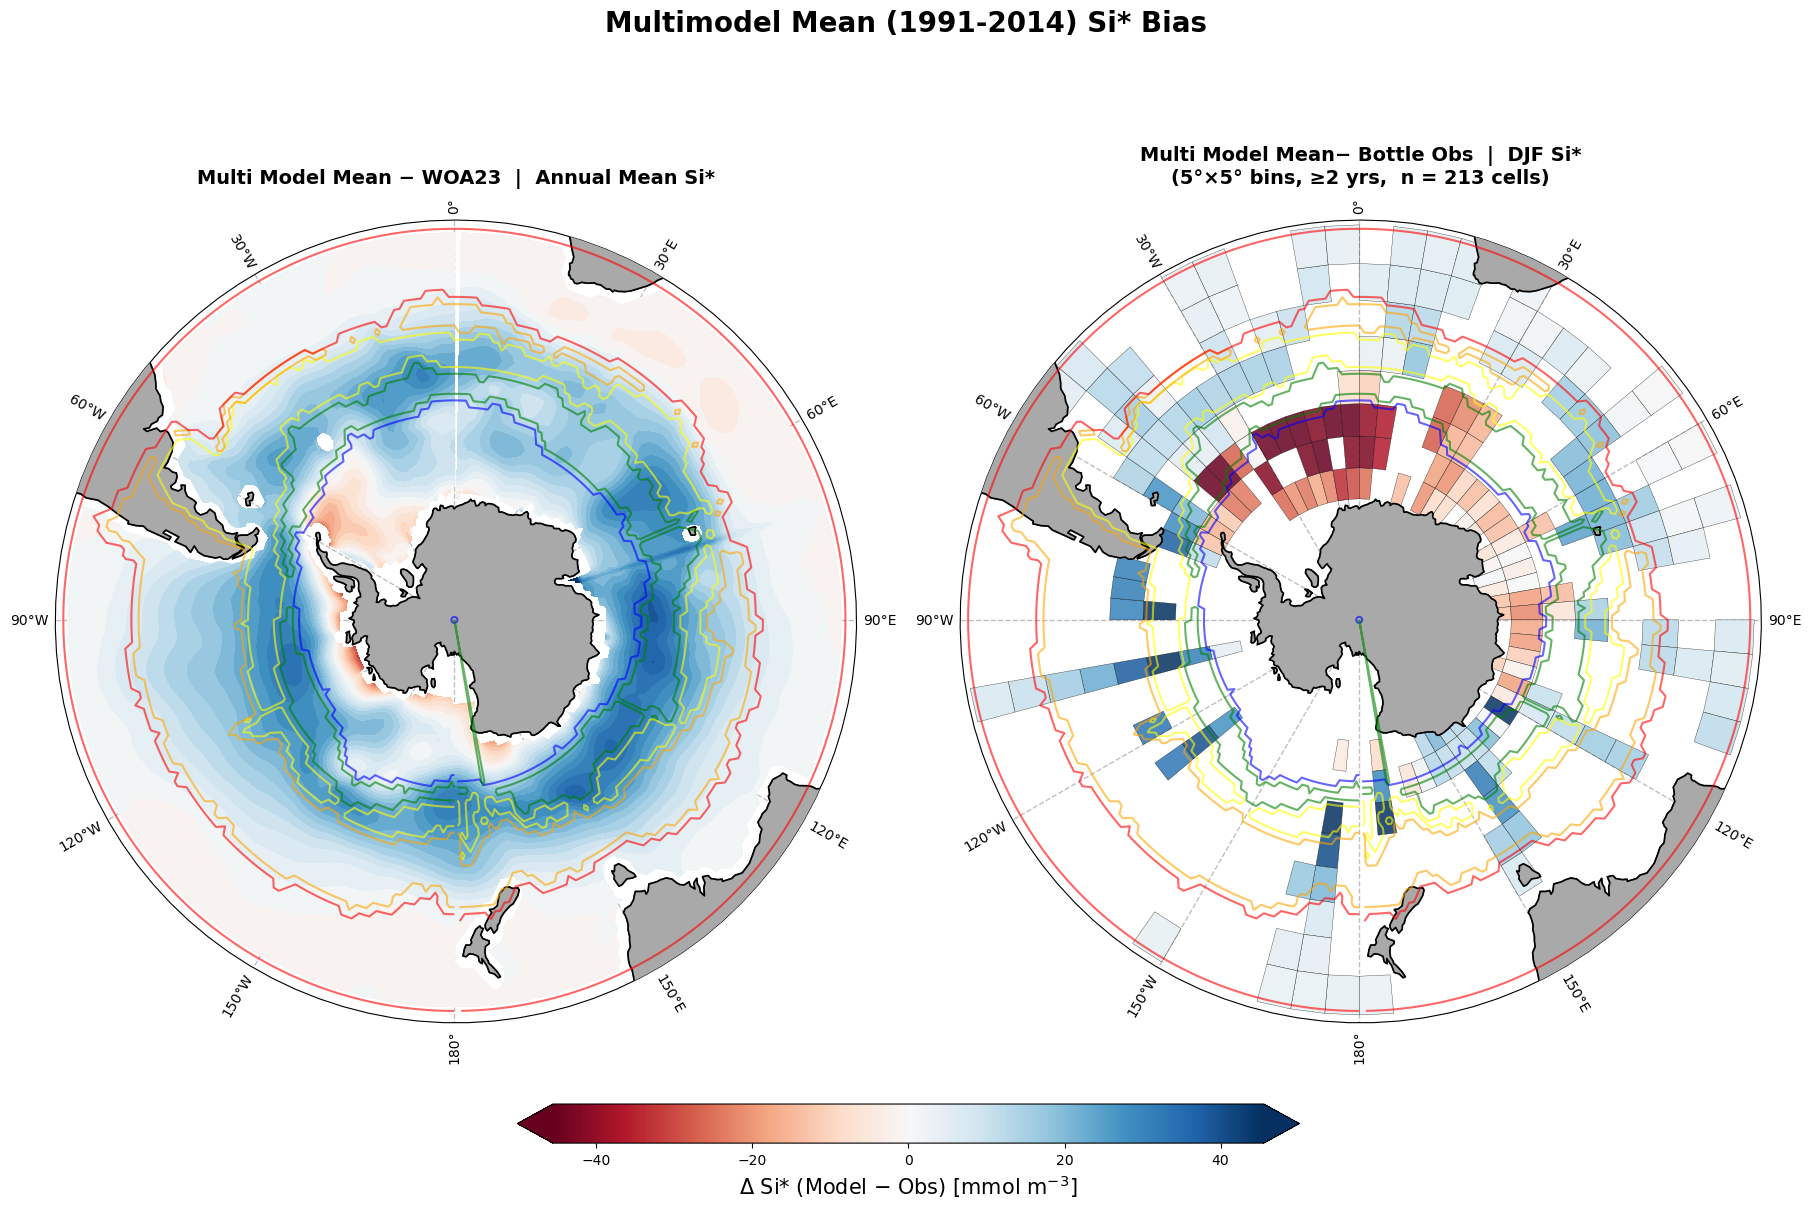

Saved → ActualFig/sistar_bias_WOA_vs_Bottle.png


In [12]:
# ============================================================
# SIDE-BY-SIDE: Model−WOA (contourf) | Model−Bottle (squares)
# ============================================================

proj = ccrs.SouthPolarStereo(central_longitude=0)
fig, axes = plt.subplots(
    1, 2,
    figsize=(18, 12),
    subplot_kw={"projection": proj},
    constrained_layout=True,
)

def setup_polar_ax(ax):
    ax.set_extent([-180, 180, -90, -29], ccrs.PlateCarree())
    ax.add_feature(cfeature.LAND,      color="darkgrey",  zorder=4)
    ax.add_feature(cfeature.OCEAN,     color="white",     zorder=1)
    ax.add_feature(cfeature.COASTLINE, linewidth=1.25,    zorder=5)
    ax.gridlines(
        crs=ccrs.PlateCarree(), draw_labels=True, linewidth=1,
        xlocs=range(-180, 171, 30), ylocs=[],
        color="gray", alpha=0.5, linestyle="--", zorder=10,
    )
    theta  = np.linspace(0, 2 * np.pi, 100)
    verts  = np.vstack([np.sin(theta), np.cos(theta)]).T
    circle = mpath.Path(verts * 0.5 + 0.5)
    ax.set_boundary(circle, transform=ax.transAxes)

Lat_mask = np.arange(-90, 90)

def draw_fronts(ax):
    for reg, mask in zone_masks.items():
        ax.contour(
            np.arange(-180, 180), Lat_mask, mask.astype(float),
            levels=[0.5], colors=region_colors[reg],
            linewidths=1.5, alpha=0.6,
            transform=ccrs.PlateCarree(), zorder=6,
        )

# ── Shared colormap limits ────────────────────────────────────────────────────
# WOA diff uses its own norm (already defined); derive a matching one for bottles
vabs_woa    = 25   # matches np.linspace(-20, 30, 35) range
vabs_bottle = np.nanpercentile(np.abs(df_diff["diff"]), 95)
vabs_shared = max(vabs_woa, vabs_bottle)
norm_shared = TwoSlopeNorm(vcenter=0, vmin=-vabs_shared, vmax=vabs_shared)
cmap_shared = "RdBu"

# ============================================================
# LEFT — Model − WOA  (contourf on full 1° grid)
# ============================================================
ax0 = axes[0]
setup_polar_ax(ax0)

Lon_woa, Lat_woa = mm.lon, mm.lat
im0 = ax0.contourf(
    Lon_woa, Lat_woa, diff,
    levels=np.linspace(-vabs_shared, vabs_shared, 35),
    cmap=cmap_shared,
    norm=norm_shared,
    extend="both",
    transform=ccrs.PlateCarree(),
    zorder=3,
)
draw_fronts(ax0)
ax0.coastlines(linewidth=0.8)
ax0.set_title("Multi Model Mean − WOA23  |  Annual Mean Si*",
              fontsize=14, fontweight="bold", pad=10)

# ============================================================
# RIGHT — Model − Bottle  (filled squares at 5°×5° bins)
# ============================================================
ax1 = axes[1]
setup_polar_ax(ax1)

for _, row in df_diff.iterrows():
    lat0 = row["lat"] - BIN / 2
    lat1 = row["lat"] + BIN / 2
    lon0 = row["lon"] - BIN / 2
    lon1 = row["lon"] + BIN / 2
    clr  = cm.get_cmap(cmap_shared)(norm_shared(row["diff"]))
    ax1.fill(
        [lon0, lon1, lon1, lon0, lon0],
        [lat0, lat0, lat1, lat1, lat0],
        color=clr, alpha=0.85,
        transform=ccrs.PlateCarree(), zorder=3,
        edgecolor="k", linewidth=0.25,
    )
draw_fronts(ax1)
ax1.coastlines(linewidth=0.8)
ax1.set_title(
    f"Multi Model Mean− Bottle Obs  |  DJF Si*\n"
    f"({BIN}°×{BIN}° bins, ≥2 yrs,  n = {len(df_diff)} cells)",
    fontsize=14, fontweight="bold", pad=10,
)

# ============================================================
# SHARED COLORBAR
# ============================================================
sm = cm.ScalarMappable(cmap=cm.get_cmap(cmap_shared), norm=norm_shared)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes, orientation="horizontal",
                    fraction=0.04, pad=0.04, extend="both",
                    shrink=0.6)
cbar.set_label("Δ Si* (Model − Obs) [mmol m$^{-3}$]", size=15)

fig.suptitle(
    "Multimodel Mean (1991-2014) Si* Bias",
    fontsize=20, fontweight="bold",
)

plt.savefig("ActualFig/sistar_bias_WOA_vs_Bottle.png",
            dpi=400, bbox_inches="tight", transparent=True)
plt.show()
print("Saved → ActualFig/sistar_bias_WOA_vs_Bottle.png")

In [15]:
# ============================================================
# DIAGNOSTIC: Mean latitude of Si* = 0 crossing
# Models, WOA23, and Hydrographic Bottles
# ============================================================
# Strategy for each source:
#   - For each longitude (or longitude bin), find the latitude
#     where Si* changes sign, then average across longitudes.
#   - Models and WOA23: use the annual-mean 2D spatial field.
#   - Bottles: use the 5°×5° binned annual mean (all seasons).
# ============================================================

from scipy.interpolate import interp1d

# ── HELPER: zero-crossing latitude at each longitude column ──────────────────
def zero_crossing_lats(lat_1d, data_2d, min_valid=5):
    """
    For a 2D field (lat × lon), find the latitude where the field
    crosses zero from positive to negative moving equatorward (S→N).
    Returns an array of crossing latitudes, one per longitude column.
    Columns with fewer than min_valid non-NaN values are skipped.
    """
    crossings = []
    nlat, nlon = data_2d.shape
    for j in range(nlon):
        col  = data_2d[:, j]
        mask = np.isfinite(col)
        if mask.sum() < min_valid:
            continue
        lats_v = lat_1d[mask]
        vals_v = col[mask]
        # Sort by latitude (S → N)
        order  = np.argsort(lats_v)
        lats_v = lats_v[order]
        vals_v = vals_v[order]
        # Find sign changes
        signs  = np.sign(vals_v)
        changes = np.where(np.diff(signs) != 0)[0]
        for idx in changes:
            # Linear interpolation between the two bracketing points
            lat_a, lat_b = lats_v[idx], lats_v[idx + 1]
            val_a, val_b = vals_v[idx], vals_v[idx + 1]
            if val_a == val_b:
                continue
            lat_cross = lat_a - val_a * (lat_b - lat_a) / (val_b - val_a)
            # Only retain crossings in the Southern Ocean
            if -70 <= lat_cross <= -25:
                crossings.append(lat_cross)
                break   # take the first (southernmost) crossing per column
    return np.array(crossings)


# ============================================================
# 1. MODELS — annual mean spatial field (all 12 months)
# ============================================================
mm_annual = xr.open_dataset(mm_path)[var].mean(dim="month")   # (lat, lon)

# Model grid: lat is -90→90, lon is 1→361
lat_mod  = mm_annual.lat.values
data_mod = mm_annual.values   # (nlat, nlon)

cross_mod = zero_crossing_lats(lat_mod, data_mod)
mean_mod  = np.nanmean(cross_mod)
std_mod   = np.nanstd(cross_mod)
print(f"Models  — mean Si*=0 latitude: {mean_mod:.2f}° ± {std_mod:.2f}°  "
      f"(n={len(cross_mod)} longitudes)")


# ============================================================
# 2. WOA23 — annual mean Si* = Si(OH)4 - NO3
# ============================================================
woa_dir  = "/glade/u/home/diegovar/summer2025/WOA23/"
si_woa   = xr.open_dataset(f"{woa_dir}/woa23_fullclim_i_all_an.nc",
                            decode_times=False)["i_an"].isel(depth=0)
no3_woa  = xr.open_dataset(f"{woa_dir}/woa23_fullclim_n_all_an.nc",
                            decode_times=False)["n_an"].isel(depth=0)

# Annual mean over all months, then compute Si*
sistar_woa = (si_woa - no3_woa).mean(dim="time")   # (lat, lon)

lat_woa  = sistar_woa.lat.values
data_woa = sistar_woa.values   # (nlat, nlon)

cross_woa = zero_crossing_lats(lat_woa, data_woa)
mean_woa  = np.nanmean(cross_woa)
std_woa   = np.nanstd(cross_woa)
print(f"WOA23   — mean Si*=0 latitude: {mean_woa:.2f}° ± {std_woa:.2f}°  "
      f"(n={len(cross_woa)} longitudes)")


# ============================================================
# 3. BOTTLES — 5°×5° annual mean (all seasons pooled)
# ============================================================
df_bottles["sistar"] = df_bottles["silicate"] - df_bottles["nitrate"]

bottle_annual = (
    df_bottles
    .groupby(["lat_bin", "lon_bin"])
    .agg(
        mean  = ("sistar", "mean"),
        years = ("year",   lambda x: x.nunique()),
    )
    .reset_index()
)
# Require at least 3 distinct years for the same reason as the map
bottle_annual = bottle_annual[bottle_annual["years"] >= 3].copy()

# For each occupied lon_bin, find the zero crossing across lat_bins
cross_bot = []
for lon_b, grp in bottle_annual.groupby("lon_bin"):
    grp_sorted = grp.sort_values("lat_bin")
    lats = grp_sorted["lat_bin"].values.astype(float)
    vals = grp_sorted["mean"].values.astype(float)
    if len(lats) < 3:
        continue
    signs   = np.sign(vals)
    changes = np.where(np.diff(signs) != 0)[0]
    for idx in changes:
        lat_a, lat_b = lats[idx], lats[idx + 1]
        val_a, val_b = vals[idx], vals[idx + 1]
        if val_a == val_b:
            continue
        lat_cross = lat_a - val_a * (lat_b - lat_a) / (val_b - val_a)
        if -70 <= lat_cross <= -25:
            cross_bot.append(lat_cross)
            break

cross_bot = np.array(cross_bot)
mean_bot  = np.nanmean(cross_bot)
std_bot   = np.nanstd(cross_bot)
print(f"Bottles — mean Si*=0 latitude: {mean_bot:.2f}° ± {std_bot:.2f}°  "
      f"(n={len(cross_bot)} lon bins)")


# ============================================================
# SUMMARY TABLE
# ============================================================
print("\n── Si* = 0 Crossing Latitude Summary ──────────────────")
print(f"{'Source':<12}  {'Mean (°S)':>10}  {'Std (°)':>8}  {'N crossings':>12}")
print("-" * 48)
for label, mean_v, std_v, n_v in [
    ("Models",   mean_mod, std_mod, len(cross_mod)),
    ("WOA23",    mean_woa, std_woa, len(cross_woa)),
    ("Bottles",  mean_bot, std_bot, len(cross_bot)),
]:
    print(f"{label:<12}  {mean_v:>10.2f}  {std_v:>8.2f}  {n_v:>12d}")

Models  — mean Si*=0 latitude: -41.93° ± 4.23°  (n=142 longitudes)
WOA23   — mean Si*=0 latitude: -58.64° ± 4.95°  (n=360 longitudes)
Bottles — mean Si*=0 latitude: -48.34° ± 9.18°  (n=53 lon bins)

── Si* = 0 Crossing Latitude Summary ──────────────────
Source         Mean (°S)   Std (°)   N crossings
------------------------------------------------
Models            -41.93      4.23           142
WOA23             -58.64      4.95           360
Bottles           -48.34      9.18            53
